# Simple Battery with static prices using Gurobi
version 2

In [1]:
# Let's load in the necessary packages

import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import beta

In [2]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "datetime", "he", "size","flexible","price","mkt_price", "ail"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

# We will need to fix the datetime string, because when R saves it into csv a 'T' and a 'Z' appear
merit_data['datetime'] = merit_data['datetime'].str.replace('T',' ').str.replace('Z','')
merit_data

FileNotFoundError: [Errno 2] No such file or directory: 'marco_data.csv'

In [159]:
# Getting market prices from the data:
mkt_prices = merit_data.groupby(by = 'datetime',as_index = False)['mkt_price'].min()['mkt_price']

# Getting the "time list" for convenience too.
time_index = merit_data['datetime'].unique()

In [160]:
# Loading in battery data:

#### BATTERY DATA ####

# Creating the parameters of the battery here, and if we want to make changes to our battery this is where we can adjust it.
batt_dict = {
    'max_charge_rate':100,
    'max_discharge_rate':100,
    'capacity':400,
    'charge_eff':0.05,
    'discharge_eff':0.05,
    'min_soc':0.05,
    'max_soc':0.95,
    'initial_soc':200
}

battDF = pd.DataFrame.from_dict(batt_dict, orient = 'index').transpose()
del batt_dict
battDF

,max_charge_rate,max_discharge_rate,capacity,charge_eff,discharge_eff,min_soc,max_soc,initial_soc
0,100.0,100.0,400.0,0.05,0.05,0.05,0.95,200.0


In [161]:
# Now let's construct a loop that gets all the mixed beta parameters for each price curve for each hour

# First we define the weighted mixture of two Beta CDFs
def mixture_beta_cdf(x, alpha1, beta1, alpha2, beta2, w):
    beta_cdf1 = beta.cdf(x, alpha1, beta1)
    beta_cdf2 = beta.cdf(x, alpha2, beta2)
    return w * beta_cdf1 + (1 - w) * beta_cdf2

# And then make a list for each of the parameters since we're doing it for all hours:
alpha1_fitlist = []
beta1_fitlist = []
alpha2_fitlist = []
beta2_fitlist = []
w_fitlist = []
# Getting max and min values to help with normalization:
merit_max = []
merit_min = []

for i in range(len(time_index)):

    bids = merit_data[merit_data['datetime']==time_index[i]]
    bids=bids.sort_values('price').reset_index(drop = True)
    # bids=bids.assign(merit=bids['size'].cumsum())
    bids['merit'] = bids['size'].cumsum() # Old code is above

    # Getting values for x and y to use for approximating the beta function
    bids_temp=bids
    x = bids_temp['merit']
    x = x.to_numpy()
    y = bids_temp['price']

   # Normalize the domain (x) to [0, 1]
    x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))

    # Normalize the range (y) to [0, 1]
    y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))

    # Fit the mixture Beta CDF to the normalized data
    popt, _ = curve_fit(mixture_beta_cdf, x_normalized, y_normalized, p0=[2, 5, 5, 2, 0.5])

    # Retrieve fitted parameters
    alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted = popt

    # Putting parameters in the respective lists
    alpha1_fitlist.append(alpha1_fitted)
    beta1_fitlist.append(beta1_fitted)
    alpha2_fitlist.append(alpha2_fitted)
    beta2_fitlist.append(beta2_fitted)
    w_fitlist.append(w_fitted)
    merit_max.append(np.max(x))
    merit_min.append(np.min(x))

# We will now have lists of parameters that can give us the approximated price

In [162]:
# Now let's use the function that we have, as well as the parameters we have estimated to create a list of approximated prices.

# First, we'll have to normalize our data to use with the mixed beta function we created.
ail_minlist = merit_data.groupby(by = 'datetime',as_index = False)['size'].min()['size']
ail_maxlist = merit_data.groupby(by = 'datetime',as_index = False)['size'].sum()['size']
ail_normalized = merit_data.groupby(by = 'datetime',as_index = False)['ail'].min()['ail']
ail_normalized = ail_normalized/(ail_maxlist - ail_minlist)
del ail_minlist, ail_maxlist

approx_prices = []
# Loop to approximate prices for each hour:
for i in range(len(ail_normalized)):
    approx_prices.append(1000 * mixture_beta_cdf(ail_normalized[i],alpha1_fitlist[i],beta1_fitlist[i],alpha2_fitlist[i],beta2_fitlist[i],w_fitlist[i]))



In [163]:
# Let's compare market prices and approximated prices side by side

price_comparison = pd.DataFrame()
price_comparison['mkt_prices'] = mkt_prices
price_comparison['approx_prices'] = approx_prices
price_comparison

,mkt_prices,approx_prices
0,68.48,89.281666
1,43.83,33.467600
2,31.36,29.174127
3,30.96,20.246741
4,31.71,30.859818
5,39.92,35.675735
6,45.69,54.319951
7,32.35,21.952185
8,31.40,12.069435
9,30.43,7.586971


In [164]:
# Now we start with creating the gurobi model.

bm = gp.Model("qp")

inf = GRB.INFINITY

In [165]:
## Let's create the variables
# It's slightly different now because we're using Gurobi

# Create an index for the number of periods that's an integer; easier to use.
tIndex = len(time_index)

# Now creating the variables of a simpler battery
vBattPower = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]
# Battery State of Charge Variable, which acts as a constraint as well.
vSOC = [bm.addVar(lb = battDF.iloc[0]['capacity']*battDF.iloc[0]['min_soc'], ub = battDF.iloc[0]['capacity']*battDF.iloc[0]['max_soc'], name = "") for _ in range(tIndex)]

In [166]:
## CONSTRAINTS

for i in range(tIndex):

    #---------------------------------------------------------------------------------------------------------------------------
    #### Battery Constraints:

    # Power flow constraints
    bm.addConstr(vBattPower[i] >= -battDF.iloc[0]['max_discharge_rate'])
    bm.addConstr(vBattPower[i] <= battDF.iloc[0]['max_charge_rate'])

    # Law of Motion for the state of charge of the battery:
    # NOTE: Because we are doing it this way, if BattPower is positive then our battery is charging.
    if i == 0:
        bm.addConstr(vSOC[i] == battDF.iloc[0]['initial_soc'] + vBattPower[i])
    else:
        bm.addConstr(vSOC[i] == vSOC[i-1] + vBattPower[i])

    #---------------------------------------------------------------------------------------------------------------------------


    

In [167]:
#---------------------------------------------------------------
# Objective Function Setup

# Add objective
# Changed the objective to sum up the battery energy times the price, instead of power in the grid.
obj = 0
obj += sum([mkt_prices[i]*vBattPower[i] for i in range(tIndex)])
# obj += sum([approx_prices[i]*vBattPower[i] for i in range(tIndex)])

# Setting the objective
bm.setObjective(obj, GRB.MINIMIZE)
#---------------------------------------------------------------

In [168]:
# Command that tells gurobi to optimize the model.

bm.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 8645HS w/ Radeon 760M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 72 rows, 48 columns and 119 nonzeros
Model fingerprint: 0x25d17634
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+02]
  Bounds range     [2e+01, 4e+02]
  RHS range        [1e+02, 2e+02]
Presolve removed 49 rows and 1 columns
Presolve time: 0.01s
Presolved: 23 rows, 47 columns, 69 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.5390300e+05   2.065000e+03   0.000000e+00      0s
      10   -1.7787100e+05   0.000000e+00   0.000000e+00      0s

Solved in 10 iterations and 0.01 seconds (0.00 work units)
Optimal objective -1.778710000e+05


In [169]:
# Now let's collect the solutions, or the battery activity

BattPower = []
state_of_charge = []

for i in range(tIndex):
    BattPower.append(vBattPower[i].X)
    state_of_charge.append(vSOC[i].X)

# BattPower

In [170]:
# Let's use a graph and table to check things

battery_results = pd.DataFrame()

battery_results['datetime'] = time_index
battery_results['state_of_charge'] = state_of_charge
battery_results['BattPower'] = BattPower
battery_results['mkt_prices'] = mkt_prices
battery_results['approx_prices'] = approx_prices

battery_results

# Recall: "State of charge" is "after the fact", meaning it's after the battery does its action

,datetime,state_of_charge,BattPower,mkt_prices,approx_prices
0,2024-04-10 01:00:00,100.0,-100.0,68.48,89.281666
1,2024-04-10 02:00:00,20.0,-80.0,43.83,33.467600
2,2024-04-10 03:00:00,120.0,100.0,31.36,29.174127
3,2024-04-10 04:00:00,220.0,100.0,30.96,20.246741
4,2024-04-10 05:00:00,320.0,100.0,31.71,30.859818
5,2024-04-10 06:00:00,220.0,-100.0,39.92,35.675735
6,2024-04-10 07:00:00,120.0,-100.0,45.69,54.319951
7,2024-04-10 08:00:00,20.0,-100.0,32.35,21.952185
8,2024-04-10 09:00:00,20.0,0.0,31.40,12.069435
9,2024-04-10 10:00:00,120.0,100.0,30.43,7.586971


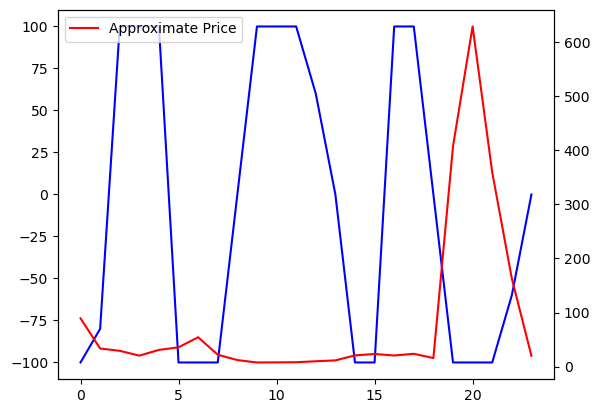

In [171]:
# Plotting the results

# And now we plot to be able to see:

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(range(tIndex),BattPower, label = "Battery Activity")
ax2.plot(range(tIndex),battery_results['approx_prices'], color = 'red', label = "Approximate Price")
# ax2.plot(range(tIndex),battery_results['mkt_prices'], color = 'red', label = "Market Price")

plt.legend()
plt.show()

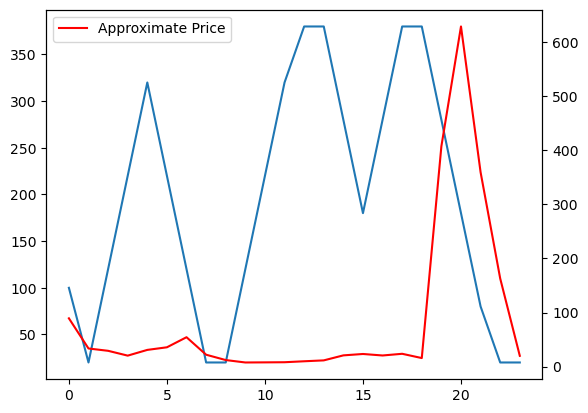

In [172]:
# Plotting the results

# And now we plot to be able to see:

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(range(tIndex),state_of_charge, label = "Battery Activity")
# ax2.plot(range(tIndex),battery_results['mkt_prices'], color = 'red', label = "Market Price")
ax2.plot(range(tIndex),battery_results['approx_prices'], color = 'red', label = "Approximate Price")

plt.legend()
plt.show()

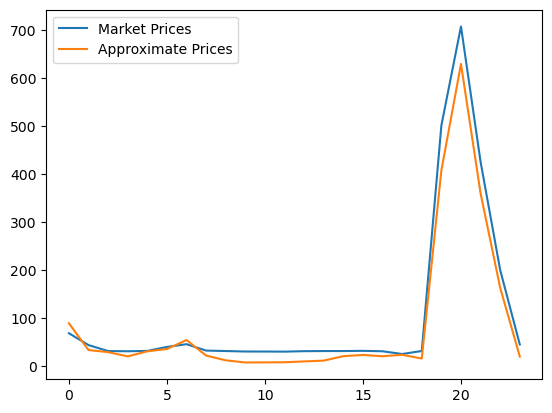

In [173]:
# Now let's make a graph that compares our approximation to actual prices:

plt.plot(range(tIndex), mkt_prices, label = 'Market Prices')
plt.plot(range(tIndex), approx_prices, label = 'Approximate Prices')
plt.legend()
plt.show()